# Cocoa Pathology Detection using YOLO26n

## Overview
This file contains the training and export pipeline for an object detection model designed to identify and localise cocoa pod health conditions. The model classifies cocoa pods into three primary categories: **Anthracnose**, **Cocoa Swollen Shoot Virus Disease (CSSVD)**, and **Healthy**.

The primary artifact produced by this workflow is an optimised ONNX format model (`yolo26n.onnx`), fine-tuned from pre-trained weights to allow low-latency deployment on edge computing local devices.

---

## Methodology & Transfer Learning

Training deep vision networks from scratch requires large quantities of annotated data and computational overhead. To optimise convergence speed and generalisability, this project utilises **transfer learning** with the **YOLO26n (Nano)** architecture:

1. **Feature Extraction:** Pre-trained weights (trained on general computer vision benchmarks) were leveraged to retain low-level spatial features such as boundaries, textures, and gradient patterns.
2. **Fine-Tuning:** The bounding-box and classification heads were retrained specifically on the cocoa dataset annotations using GPU hardware in Google Colab.
3. **Graph Optimisation:** Post-training weights (`best.pt`) were converted to ONNX FP32 format and streamlined using `onnxslim` to reduce runtime overhead and memory consumption (~9.4 MB binary size). Just like in a professional setting.

---

## Performance Summary

Validation was conducted across a dataset of 1,105 validation images containing 1,956 annotated instances.

* **mAP@50:** 92.3% overall mean Average Precision across all categories.
* **mAP@50-95:** 69.7% mean Average Precision across variable IoU thresholds (0.50 to 0.95), indicating precise bounding box localisation.
* **Precision:** 89.3% mean across classes (Anthracnose: 89.6%, CSSVD: 91.5%, Healthy: 86.8%).
* **Inference Speed:** Approximately 4.2 ms per image (batch size = 1 on Tesla T4 GPU), suitable for high-throughput batch processing or video stream execution.

---

## Code Base & Execution Log

The Python script below represents the complete computational workflow executed within the Colab environment. It includes data preparation, multi-epoch transfer learning, validation evaluation, inference testing, and final ONNX export.


In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}")

Using cuda


# Mounting the drive, set up path and imports

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
from pathlib import Path


GOOGLE_DRIVE_PATH_AFTER_MYDRIVE = 'Colab Notebooks/CocoaDiseaseDetection'
GOOGLE_DRIVE_PATH = Path('drive') / 'MyDrive' / GOOGLE_DRIVE_PATH_AFTER_MYDRIVE
print(os.listdir(GOOGLE_DRIVE_PATH))

['Code.ipynb', 'data.yaml', '.ipynb_checkpoints', 'YOLO.ipynb']


# Loading dataset

In [6]:
import kagglehub

# Downloading latest version
raw_path = kagglehub.dataset_download("ohagwucollinspatrick/amini-cocoa-contamination-dataset")

dataset_path = Path(raw_path)

print("Path to dataset files:", dataset_path)

Using Colab cache for faster access to the 'amini-cocoa-contamination-dataset' dataset.
Path to dataset files: /kaggle/input/amini-cocoa-contamination-dataset


# YOLO
Used YOLO template given in the YOLO github documentation.

In [7]:
# Install Ultralytics
%pip install -q ultralytics

# Checks installation & GPU status
from ultralytics import YOLO, checks
checks()

Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 61.0/235.7 GB disk)


# Data Cleaning and Preprocessing
For the yaml file for yolo to work I need to have a predefined folder directory.

#### **Reference**:
https://docs.ultralytics.com/datasets/detect#ultralytics-yolo-format


In [8]:
import os
import random
import shutil

# Paths
img_dir = dataset_path / "dataset" / "images" / "train"
lbl_dir = dataset_path / "dataset" / "labels" / "train"

print(f"Images path: {img_dir}")
print(f"Labels path: {lbl_dir}")

# Only adding val data in working_dir to reduce copy time. i.e. I don't have to copy every item in the dataset to working.
working_dir = Path("/kaggle/working/dataset")
val_img_dir = working_dir / "images" / "val"
val_lbl_dir = working_dir / "labels" / "val"

if not val_img_dir.exists() or not len(list(val_img_dir.iterdir())):
    """
    WHY parents=True needed?
    if I was creating just "kaggle / working" then it's fine.
    BUT
    trying to create  "kaggle / working / dataset" while no directory after
    dataset_path/kaggle exists we need to create all folders.
    """
    val_img_dir.mkdir(parents=True, exist_ok=True)
    val_lbl_dir.mkdir(parents=True, exist_ok=True)

    images = [f for f in img_dir.iterdir() if f.suffix.lower() in ('.jpg', '.jpeg', '.png')]
    random.shuffle(images)
    images_count = len(images)
    val_split_count = int(images_count * 0.2)

    for file in images[:val_split_count]:
        shutil.copy(file, (val_img_dir / file.name))

        lbl_path = lbl_dir / f"{file.stem}.txt"
        if lbl_path.exists():
            shutil.copy(lbl_path, val_lbl_dir / lbl_path.name)

    print(f"Moved {val_split_count} images to validation set")
else:
    print(f"Validation set already split and is in dedicated dir.")

Images path: /kaggle/input/amini-cocoa-contamination-dataset/dataset/images/train
Labels path: /kaggle/input/amini-cocoa-contamination-dataset/dataset/labels/train
Validation set already split and is in dedicated dir.


In [ ]:
import os
import shutil

# Create local directories
os.makedirs("/content/cocoa/dataset/images", exist_ok=True)
os.makedirs("/content/cocoa/dataset/labels", exist_ok=True)

# Copy validation images and labels from Drive to local SSD
!cp -r "/kaggle/working/dataset/images/val" /content/cocoa/dataset/images/
!cp -r "/kaggle/working/dataset/labels/val" /content/cocoa/dataset/labels/

print("Validation set moved to fast local SSD!")

Validation set moved to fast local SSD!


In [ ]:
# Load a pretrained YOLO26n model
model = YOLO("yolo26n.pt")
data_path = GOOGLE_DRIVE_PATH / "data.yaml"
print(f"Path is: {data_path}")

# Train the model on the COCO8 dataset for 100 epochs
train_results = model.train(
    data=data_path,  # Path to dataset configuration file
    epochs=50,  # Number of training epochs
    imgsz=640,  # Image size for training
    device=0,  # Device to run on (e.g., 'cpu', 0, [0,1,2,3])
    batch=32,
    workers=4,
    cache=True

    # Saving location parameters

)

print(f"Model sucessfully trained.")

Path is: drive/MyDrive/Colab Notebooks/CocoaDiseaseDetection/data.yaml
Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=True, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=drive/MyDrive/Colab Notebooks/CocoaDiseaseDetection/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=trai

## (Optional) Recovering my Trained Model
Troubleshooting my session restarting after completing training model before saving model as .onnx format.
Rookie mistake should've used a higher performing GPU and/or set cache=False (default) during model.train().

In [4]:
import os
from ultralytics import YOLO

# Load your newly trained model weights
best_model_path = "/content/runs/detect/train/weights/best.pt"

model = YOLO(best_model_path)
print("Trained model successfully loaded from memory.")

Trained model successfully loaded from memory.


# Evaluating and Saving the model

### Key Takeaway:

The Yolo26n lightweight model performed exceptionally well against this agricultural dataset acheiving an overall **mAP50 of 92/3%** and **Precision of 0.893 (89.3%)** across the validation set. <br>


**Major Drawback/Limitation**
- No Unseen Test Set: Because this originates from Kaggle competition dataset where test labels are withheld, evaluation was limited to 20% validation set.

In [10]:

# Evaluate the model's performance on the validation set
metrics = model.val()

Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2456.1±553.4 MB/s, size: 178.1 KB)
val: Scanning /content/cocoa/dataset/labels/val.cache... 1105 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1105/1105 309.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 70/70 1.0s/it 1:13
                   all       1105       1956      0.893      0.845      0.923      0.697
           anthracnose        324        474      0.896      0.854      0.918      0.701
                 cssvd        432        618      0.915      0.819      0.924        0.7
               healthy        349        864      0.868      0.861      0.929      0.689
Speed: 1.7ms preprocess, 4.2ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /content/runs/detect/val-3


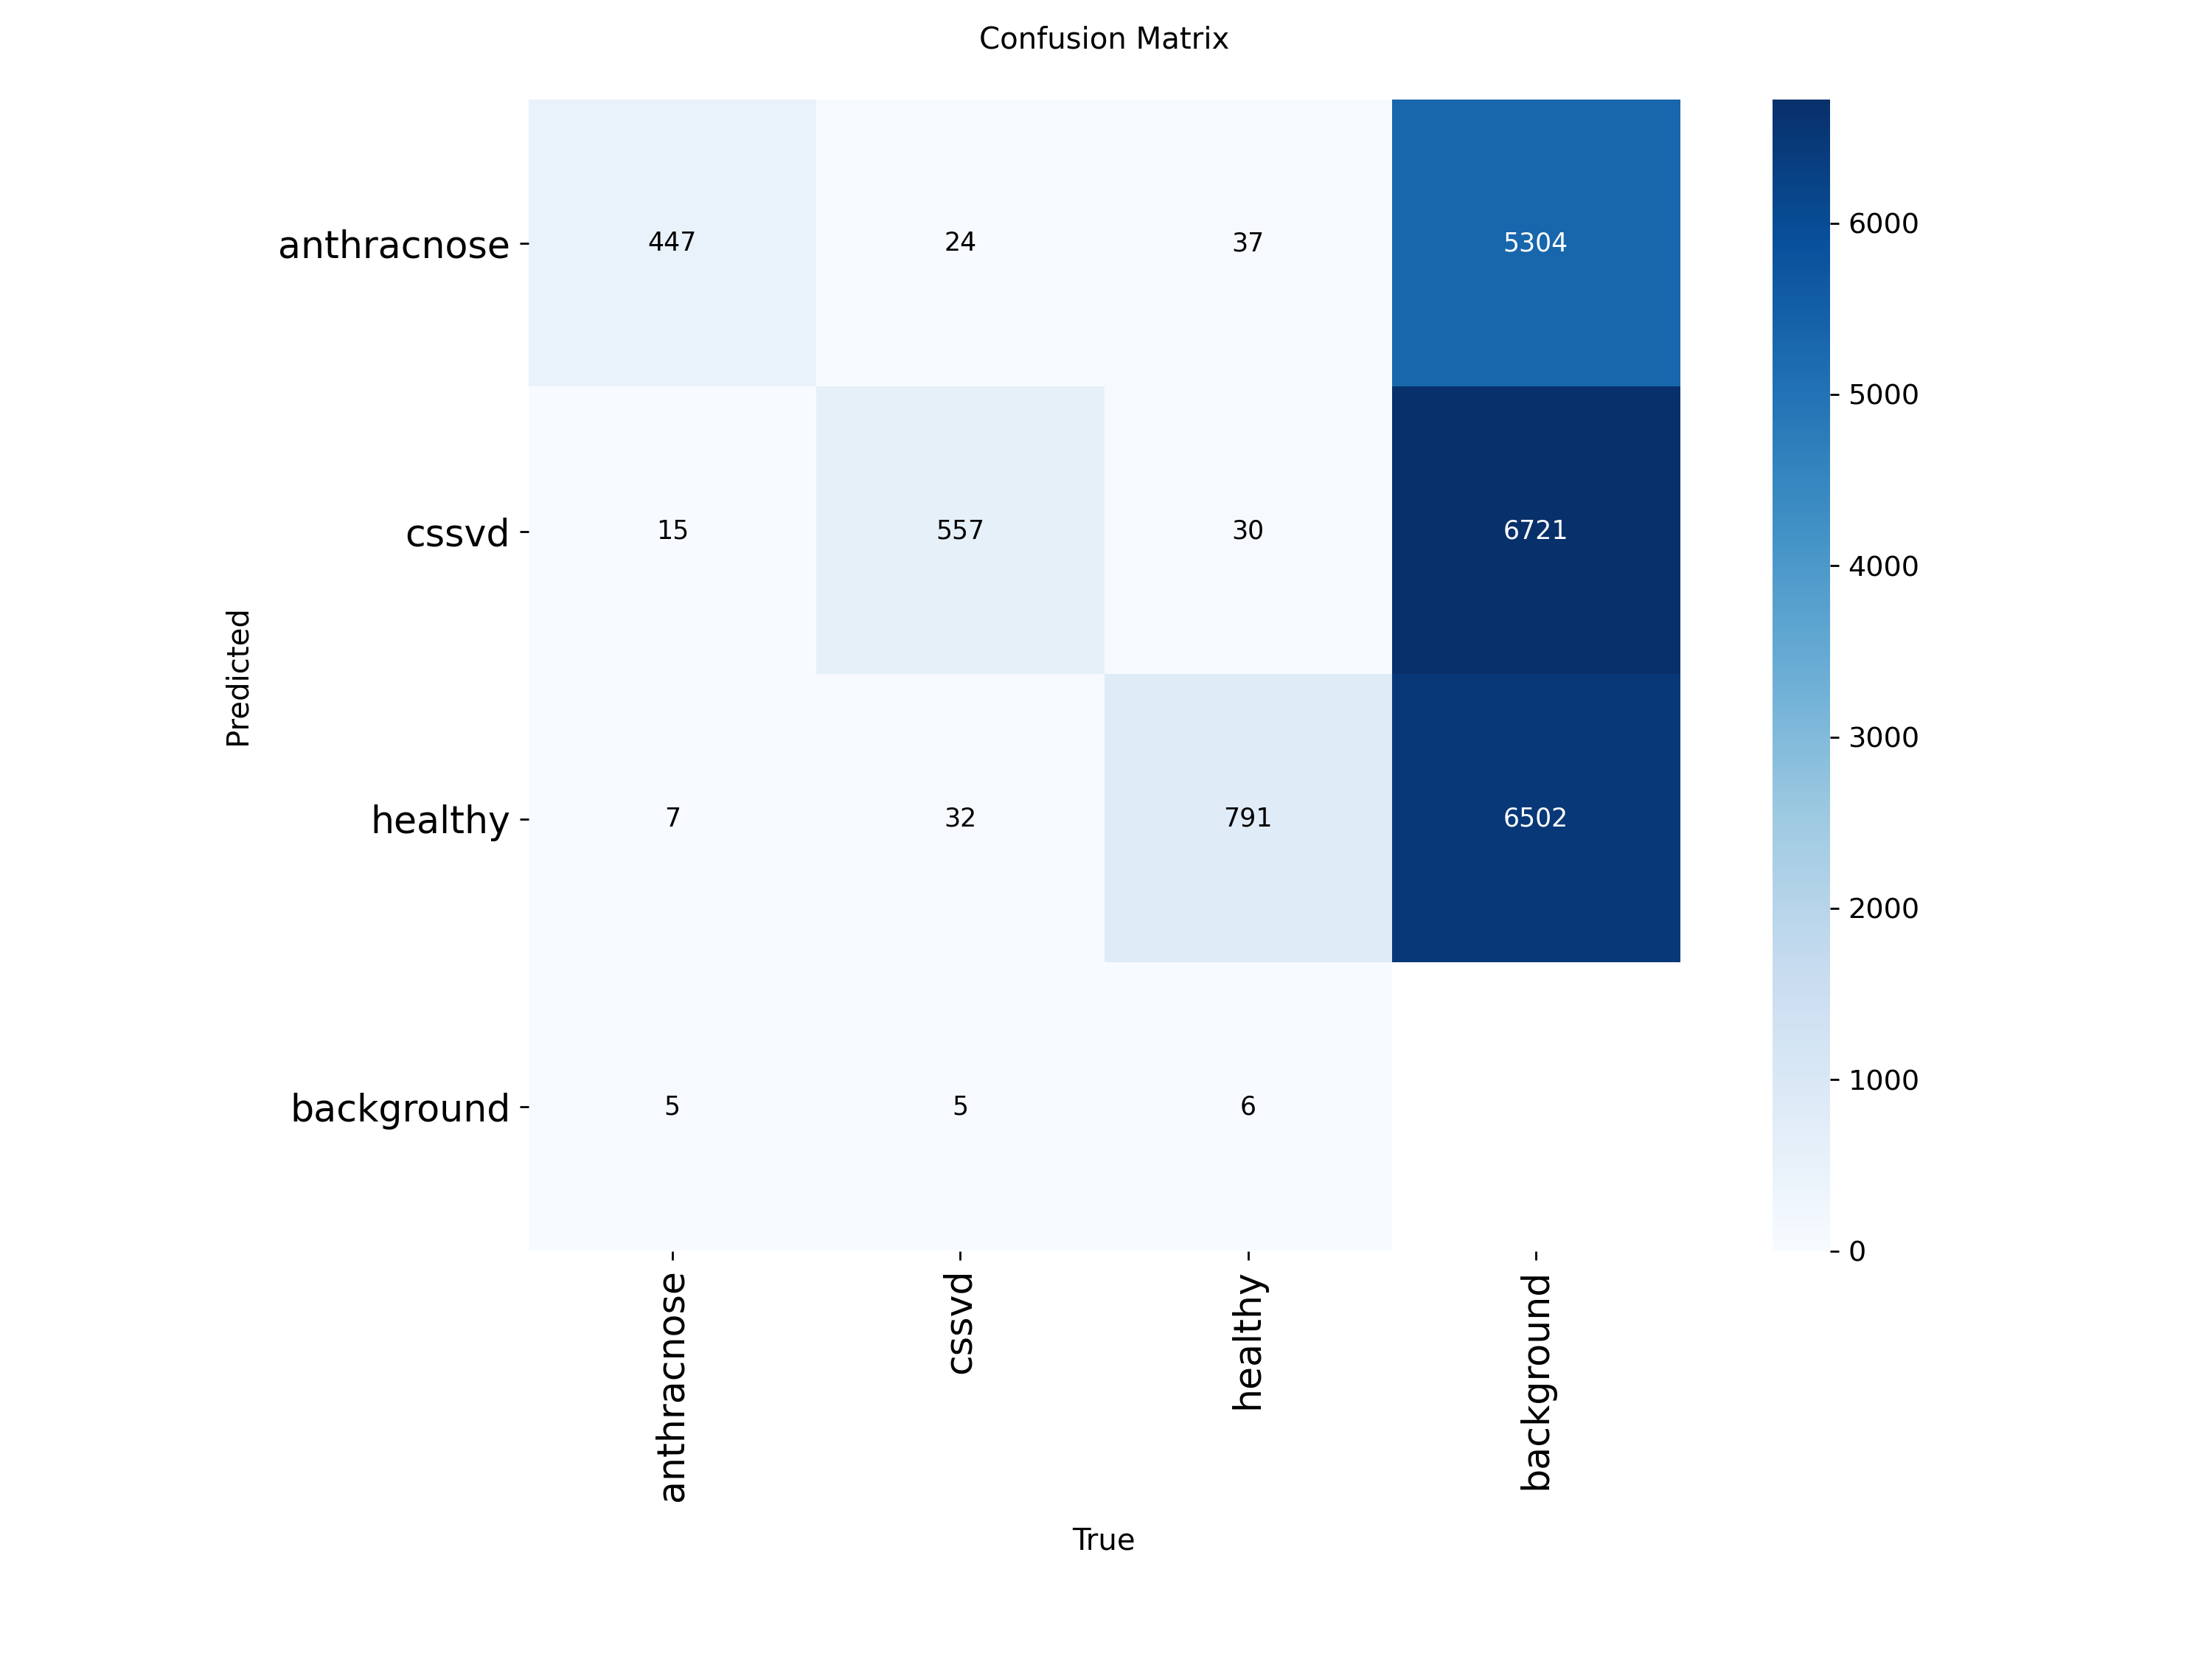

In [13]:
from IPython.display import Image, display

# Displaying the confusion matrix YOLO already created inside runs/detect
display(Image(filename='/content/runs/detect/val-3/confusion_matrix.png'))

### Saving model in .onnx


image 1/1 /kaggle/input/amini-cocoa-contamination-dataset/dataset/images/train/ID_YWCFYI.jpg: 640x640 2 healthys, 9.9ms
Speed: 4.9ms preprocess, 9.9ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


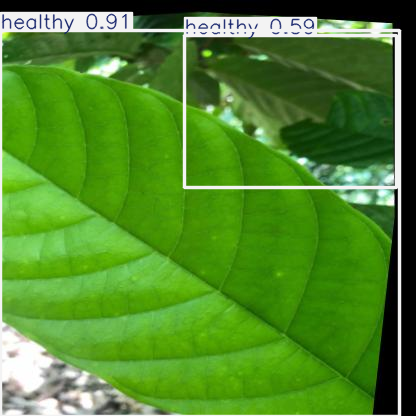

Ultralytics 8.4.114 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 289ms
Prepared 4 packages in 1.87s
Installed 4 packages in 267ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.28.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 3.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 6.1s, saved as '/content/runs/detect/t

'drive/MyDrive/Colab Notebooks/CocoaDiseaseDetection/yolo26n.onnx'

In [11]:

# Perform object detection on an image
path_to_image = img_dir / "ID_YWCFYI.jpg"
results = model(path_to_image)  # Predict on an image
results[0].show()

# Export the model to ONNX format for deployment
path = model.export(format="onnx")  # Returns the path to the exported model

print(path)

# If wanted to change the path of the file.
shutil.move(path, os.path.join(GOOGLE_DRIVE_PATH, "yolo26n.onnx"))